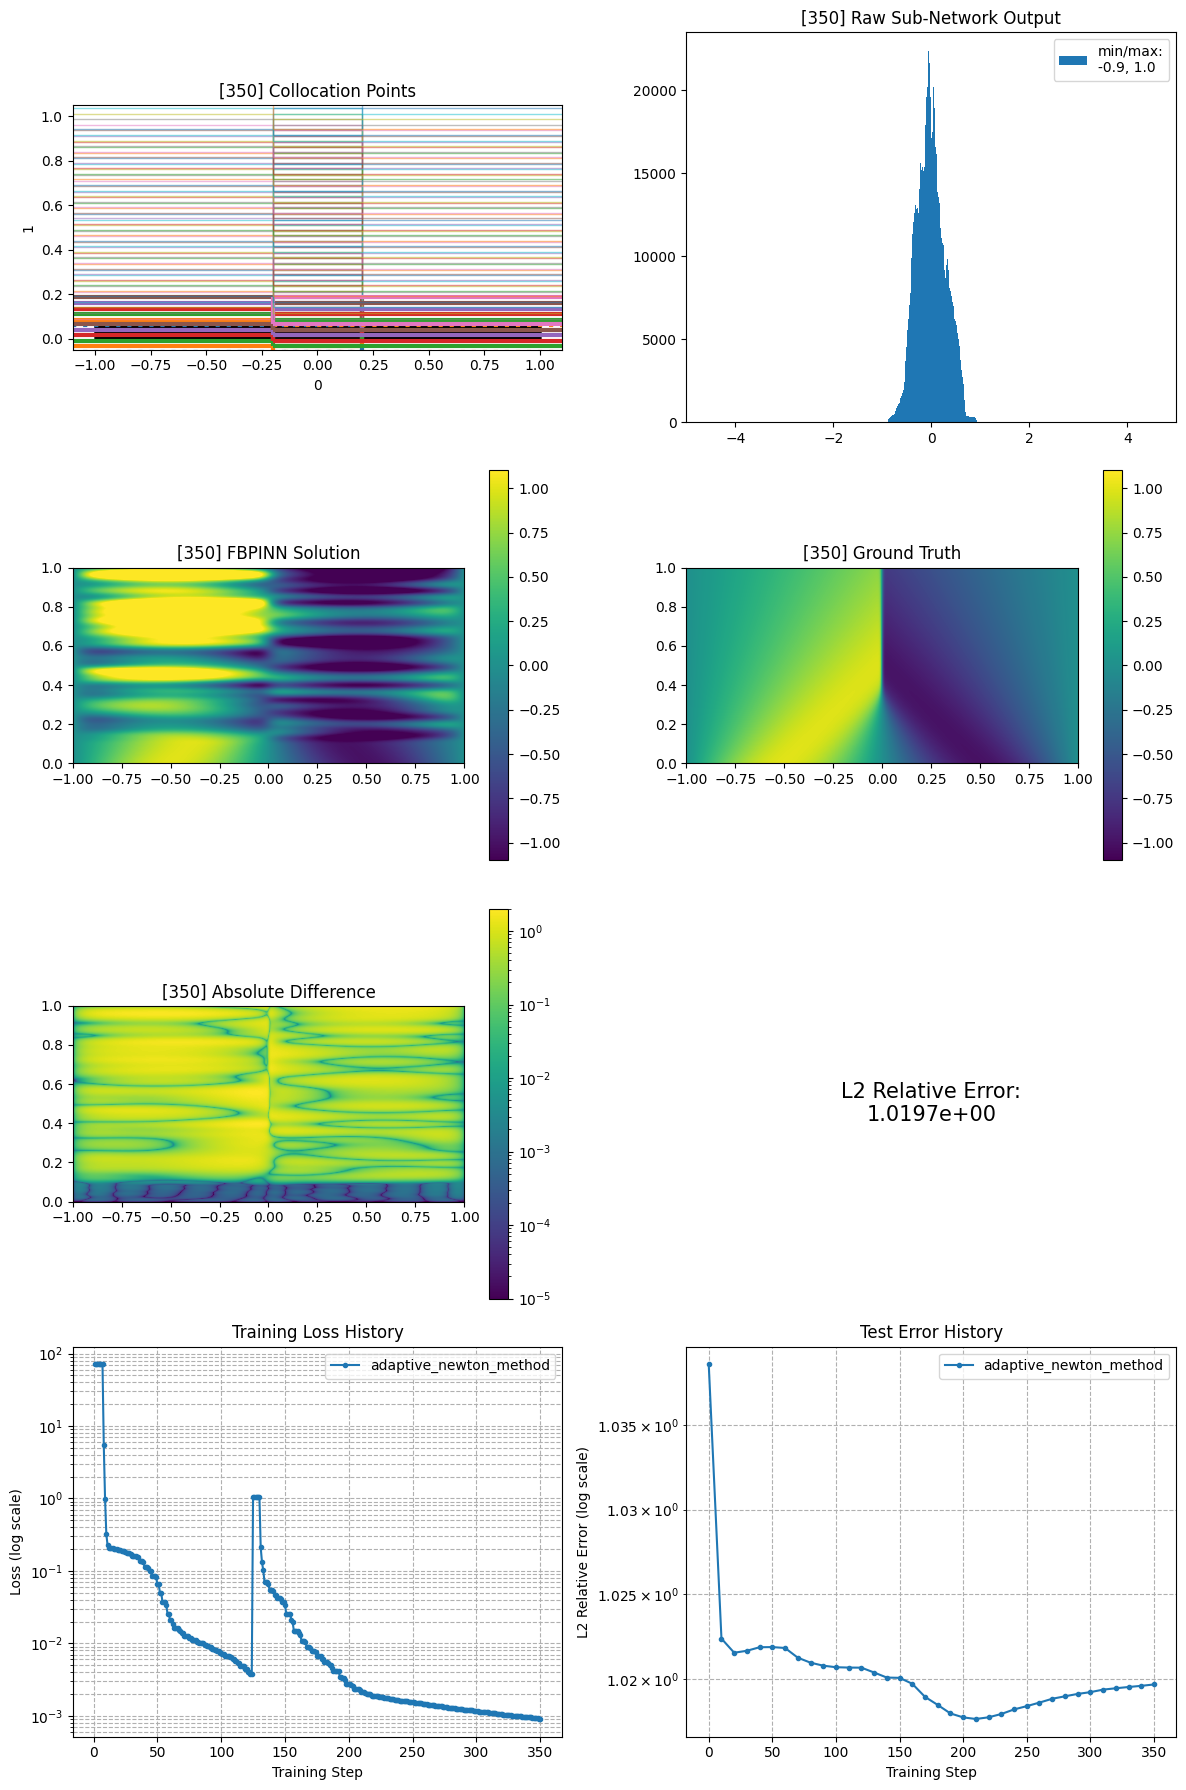

[INFO] 2025-07-01 04:40:45 - [i: 371/10000] Updating active inputs..
[INFO] 2025-07-01 04:40:49 - [i: 371/10000] Average number of points/dimension in active subdomains: 94.36
[INFO] 2025-07-01 04:40:54 - [i: 371/10000] Updating active inputs done (8.31 s)
[INFO] 2025-07-01 04:40:54 - [i: 371/10000] Initialising new state.
[INFO] 2025-07-01 04:40:54 - [i: 371/10000] Compiling update step..
[INFO] 2025-07-01 04:40:54 - x_batch
[INFO] 2025-07-01 04:40:54 - (14848, 2), float32, JVPTracer
[INFO] 2025-07-01 04:40:54 - x_take
[INFO] 2025-07-01 04:40:54 - (78592, 2), float32, JVPTracer
[INFO] 2025-07-01 04:40:54 - x_batch
[INFO] 2025-07-01 04:40:54 - (14848, 2), float32, JVPTracer
[INFO] 2025-07-01 04:40:54 - x_take
[INFO] 2025-07-01 04:40:54 - (78592, 2), float32, JVPTracer
[INFO] 2025-07-01 04:40:54 - x_batch
[INFO] 2025-07-01 04:40:54 - (14848, 2), float32, JVPTracer
[INFO] 2025-07-01 04:40:54 - x_take
[INFO] 2025-07-01 04:40:54 - (78592, 2), float32, JVPTracer
[INFO] 2025-07-01 04:40:55 -

2025-07-01 04:41:01.200740: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3020] Can't reduce memory use below 5.70GiB (6118932862 bytes) by rematerialization; only reduced to 7.58GiB (8143819792 bytes), down from 7.59GiB (8149770028 bytes) originally


[INFO] 2025-07-01 04:41:04 - [i: 371/10000] Compiling done (10.14 s)


2025-07-01 04:41:14.259578: W external/xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.62GiB (rounded to 8187459840)requested by op 
2025-07-01 04:41:14.260144: W external/xla/xla/tsl/framework/bfc_allocator.cc:508] ***_________________________________________________________________________________________________
E0701 04:41:14.260250   38117 pjrt_stream_executor_client.cc:3085] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 8187459760 bytes.


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 8187459760 bytes.

In [ ]:
import numpy as np

from fbpinns.domains import RectangularDomainND
from fbpinns.problems import BurgersEquation2D
from fbpinns.decompositions import RectangularDecompositionND
from fbpinns.networks import FCN
from fbpinns.schedulers import LineSchedulerRectangularND
from fbpinns.constants import Constants, get_subdomain_ws
from fbpinns.trainers import FBPINNTrainer

import optax

from fbpinns.optimisers import adaptive_newton_method

subdomain_xs=[np.array([-0.5,0.5]), np.linspace(0,1,41)]
subdomain_ws=[np.array([1.4, 1.4]), np.array([0.12,] * len(subdomain_xs[1]))]

c = Constants(
    domain=RectangularDomainND,
    domain_init_kwargs = dict(
        xmin=np.array([-1,0.]),
        xmax=np.array([1.,1.])
        ),
    problem=BurgersEquation2D,
    problem_init_kwargs = dict(),
    decomposition=RectangularDecompositionND,
    decomposition_init_kwargs=dict(
        subdomain_xs=subdomain_xs,
        subdomain_ws=subdomain_ws,
        unnorm=(0.,3.),
    ),
    network=FCN,
    network_init_kwargs = dict(
        layer_sizes = (2, 6, 1),
    ),
    scheduler = LineSchedulerRectangularND,
    scheduler_kwargs = dict(
        point=[0.], iaxis=0,
    ),
    
    # sampler="sobol",
    
    ns=((512,256),),
    n_test=(512,256),
    clear_output=True,
    
    test_freq=1000 / 100,
    
    optimiser_schedule=[
        (adaptive_newton_method, 10000, dict(
            learning_rate=1.0,
            initial_damping=1e-2,
            min_damping=1e-4,
            damping_increase_factor=5.0,
            damping_decrease_factor=5.0,
            max_update_norm=10_000,
        )),
    ],
)

run = FBPINNTrainer(c)
all_params = run.train()